In [ ]:
from google.colab import drive
drive.mount('/content/drive')


KeyboardInterrupt: 

In [ ]:
%cd drive/MyDrive/

/content/drive/MyDrive


In [ ]:
mkdir CSRNet

In [ ]:
%cd /content/drive/MyDrive/CSRNet/datasets


/content/drive/MyDrive/CSRNet/datasets


In [ ]:
mkdir datasets

In [ ]:
%cd ..

/content


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d tthien/shanghaitech


Dataset URL: https://www.kaggle.com/datasets/tthien/shanghaitech
License(s): unknown
100% 332M/333M [00:02<00:00, 121MB/s] 
100% 333M/333M [00:02<00:00, 134MB/s]


In [ ]:
!unzip shanghaitech.zip



Archive:  shanghaitech.zip
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_1.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_10.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_100.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_101.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_102.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_103.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_104.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_105.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_106.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_107.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_108.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_109.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_11.mat  
  inflating: ShanghaiTech/pa

In [ ]:
import os

BASE = "/content/drive/MyDrive/CSRNet"

os.makedirs(f"{BASE}/datasets", exist_ok=True)
os.makedirs(f"{BASE}/checkpoints", exist_ok=True)

print("Project folders created")


Project folders created


In [ ]:
!pip install h5py scipy pillow tqdm


In [ ]:
import os
import h5py
import scipy.io as io
import numpy as np
from PIL import Image
from scipy.ndimage import gaussian_filter
from tqdm import tqdm


In [ ]:
root = "/content/drive/MyDrive/CSRNet/datasets/ShanghaiTech/part_B/train_data"
img_dir = f"{root}/images"
gt_dir = f"{root}/ground-truth"
save_dir = f"{root}/density_maps"

os.makedirs(save_dir, exist_ok=True)

def generate_density_map(img, points):
    density = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)
    for p in points:
        x = min(int(p[0]), img.shape[1]-1)
        y = min(int(p[1]), img.shape[0]-1)
        density[y, x] += 1
    return gaussian_filter(density, sigma=15)

print("Generating density maps (Part-B TRAIN)...")

for img_name in tqdm(os.listdir(img_dir)):
    if not img_name.endswith(".jpg"):
        continue

    img = np.array(Image.open(f"{img_dir}/{img_name}").convert("RGB"))
    mat = io.loadmat(f"{gt_dir}/GT_{img_name.replace('.jpg','.mat')}")
    points = mat["image_info"][0][0][0][0][0]

    density = generate_density_map(img, points)

    with h5py.File(f"{save_dir}/{img_name.replace('.jpg','.h5')}", "w") as f:
        f["density"] = density

print("✅ Density maps created")


Generating density maps (Part-B TRAIN)...


100%|██████████| 400/400 [07:02<00:00,  1.06s/it]

✅ Density maps created


In [ ]:
len(os.listdir(save_dir))


400

In [ ]:
import torch
import torch.nn as nn
from torchvision import models


In [ ]:
class CSRNet(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(pretrained=True)
        self.frontend = nn.Sequential(*list(vgg.features.children())[:23])

        self.backend = nn.Sequential(
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(512,256,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(256,128,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(128,64,3,padding=2,dilation=2), nn.ReLU()
        )

        self.output = nn.Conv2d(64,1,1)

    def forward(self,x):
        x = self.frontend(x)
        x = self.backend(x)
        return self.output(x)


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F


In [ ]:
class CrowdDataset(Dataset):
    def __init__(self, img_dir, den_dir):
        self.imgs = [
            f for f in os.listdir(img_dir)
            if f.endswith(".jpg") and os.path.exists(f"{den_dir}/{f.replace('.jpg','.h5')}")
        ]
        self.img_dir = img_dir
        self.den_dir = den_dir

        self.transform = transforms.Compose([
            transforms.Resize((288,512)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        name = self.imgs[idx]
        img = self.transform(Image.open(f"{self.img_dir}/{name}").convert("RGB"))

        with h5py.File(f"{self.den_dir}/{name.replace('.jpg','.h5')}", "r") as f:
            density = torch.from_numpy(np.array(f["density"])).unsqueeze(0).unsqueeze(0)

        density = F.interpolate(density, size=(36,64), mode="bilinear", align_corners=False)
        density *= (density.numel() / (36*64))

        return img, density.squeeze(0)


In [ ]:
def weighted_mse(pred, gt):
    """
    Weighted MSE loss for CSRNet
    Emphasizes dense crowd regions
    """
    weight = torch.ones_like(gt)
    weight[gt > 0] = 5.0
    return torch.mean(weight * (pred - gt) ** 2)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CSRNet().to(device)

criterion = weighted_mse
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.9MB/s]


In [ ]:
train_img = "/content/drive/MyDrive/CSRNet/datasets/ShanghaiTech/part_B/train_data/images"
train_den = "/content/drive/MyDrive/CSRNet/datasets/ShanghaiTech/part_B/train_data/density_maps"

train_loader = DataLoader(
    CrowdDataset(train_img, train_den),
    batch_size=1,
    shuffle=True
)


In [ ]:
from tqdm import tqdm
import math

# =============================
# TRAINING CONFIG
# =============================
EPOCHS = 200    # research-level
best_mae = float("inf")

# ✅ LEARNING RATE SCHEDULER (DEFINED HERE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-7
)

for epoch in range(1, EPOCHS + 1):

    # =============================
    # TRAIN
    # =============================
    model.train()
    train_loss = 0.0

    for imgs, dens in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        imgs, dens = imgs.to(device), dens.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, dens)
        loss.backward()

        #stability for long training
        torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # =============================
    # VALIDATION (every 2 epochs)
    # =============================
    if epoch % 2 == 0:
        model.eval()
        mae = 0.0
        mse = 0.0

        with torch.no_grad():
            for imgs, dens in train_loader:  # train set as proxy (faster)
                imgs, dens = imgs.to(device), dens.to(device)
                outputs = model(imgs)

                diff = outputs.sum() - dens.sum()
                mae += abs(diff).item()
                mse += diff.item() ** 2

        mae /= len(train_loader)
        rmse = math.sqrt(mse / len(train_loader))

        #SCHEDULER USED HERE
        scheduler.step(mae)

        current_lr = optimizer.param_groups[0]["lr"]

        print("\n==============================")
        print(f"Epoch      : {epoch}")
        print(f"Train Loss : {train_loss:.6f}")
        print(f"MAE        : {mae:.2f}")
        print(f"RMSE       : {rmse:.2f}")
        print(f"LR         : {current_lr:.8f}")
        print("==============================")

        if mae < best_mae:
            best_mae = mae
            torch.save(
                model.state_dict(),
                "/content/drive/MyDrive/CSRNet/checkpoints/best_csrnet.pth"
            )
            print("🔥 BEST MODEL SAVED")

    # Always save last model
    torch.save(
        model.state_dict(),
        "/content/drive/MyDrive/CSRNet/checkpoints/last_csrnet.pth"
    )


Epoch 2/200: 100%|██████████| 400/400 [00:45<00:00,  8.79it/s]



Epoch      : 2
Train Loss : 0.000090
MAE        : 4.75
RMSE       : 5.46
LR         : 0.00001000
🔥 BEST MODEL SAVED


Epoch 4/200: 100%|██████████| 400/400 [00:44<00:00,  8.98it/s]



Epoch      : 4
Train Loss : 0.000047
MAE        : 2.48
RMSE       : 3.07
LR         : 0.00001000
🔥 BEST MODEL SAVED


Epoch 6/200: 100%|██████████| 400/400 [00:44<00:00,  8.99it/s]


...


Epoch      : 196
Train Loss : 0.000000
MAE        : 0.08
RMSE       : 0.09
LR         : 0.00000063


Epoch 198/200: 100%|██████████| 400/400 [00:44<00:00,  9.04it/s]



Epoch      : 198
Train Loss : 0.000000
MAE        : 0.04
RMSE       : 0.05
LR         : 0.00000063


Epoch 200/200: 100%|██████████| 400/400 [00:44<00:00,  8.94it/s]



Epoch      : 200
Train Loss : 0.000000
MAE        : 0.05
RMSE       : 0.06
LR         : 0.00000063


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

from torchvision import transforms
from PIL import Image


In [ ]:
import torch.nn as nn
from torchvision import models

class CSRNet(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(pretrained=True)
        self.frontend = nn.Sequential(*list(vgg.features.children())[:23])

        self.backend = nn.Sequential(
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(512,512,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(512,256,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(256,128,3,padding=2,dilation=2), nn.ReLU(),
            nn.Conv2d(128,64,3,padding=2,dilation=2), nn.ReLU()
        )

        self.output = nn.Conv2d(64,1,1)

    def forward(self,x):
        x = self.frontend(x)
        x = self.backend(x)
        return self.output(x)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Baseline CSRNet (ImageNet pretrained only)
csrnet_baseline = CSRNet().to(device)
csrnet_baseline.eval()

# Your trained CSRNet
csrnet_trained = CSRNet().to(device)
csrnet_trained.load_state_dict(
    torch.load("/content/drive/MyDrive/CSRNet/checkpoints/best_csrnet.pth",
               map_location=device)
)
csrnet_trained.eval()

print("✅ Both models loaded")


✅ Both models loaded


In [ ]:
transform = transforms.Compose([
    transforms.Resize((288,512)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


In [ ]:
test_img_dir = "/content/drive/MyDrive/CSRNet/datasets/ShanghaiTech/part_B/test_data/images"
test_den_dir = "/content/drive/MyDrive/CSRNet/datasets/ShanghaiTech/part_B/test_data/density_maps"


In [ ]:
def load_gt_density(h5_path):
    """
    Safely load GT density.
    Returns None if file is invalid.
    """
    try:
        with h5py.File(h5_path, "r") as f:
            if "density" in f:
                return np.array(f["density"])
            else:
                return None
    except Exception:
        return None


In [ ]:
def csrnet_count(pred_density, orig_h=288, orig_w=512):
    """
    Rescale CSRNet output to preserve count
    """
    h, w = pred_density.shape
    scale = (orig_h * orig_w) / (h * w)
    return pred_density.sum() * scale


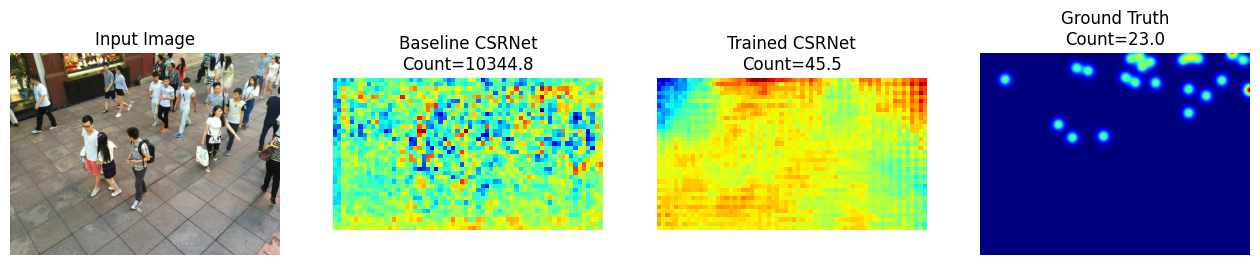

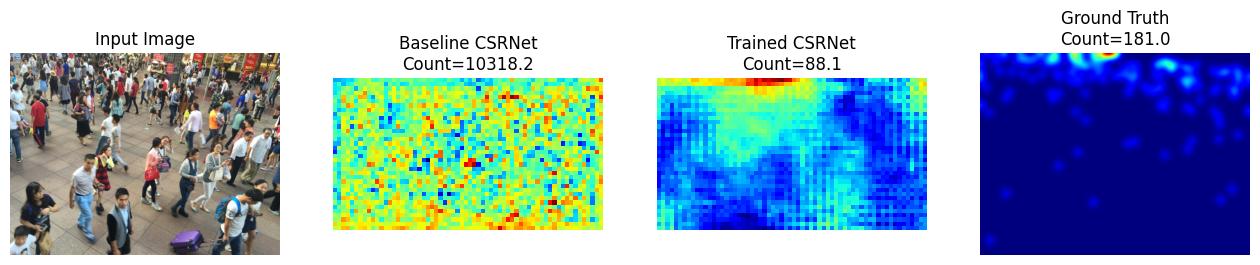

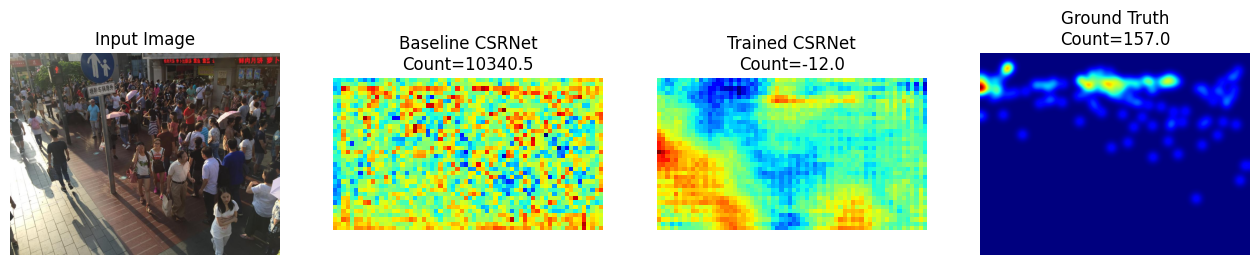

In [ ]:
test_images = sorted(os.listdir(test_img_dir))[:3]

for img_name in test_images:
    img_path = os.path.join(test_img_dir, img_name)
    h5_path = os.path.join(test_den_dir, img_name.replace(".jpg",".h5"))

    gt_density = load_gt_density(h5_path)
    if gt_density is None:
        print(f"Skipping {img_name} (invalid GT)")
        continue

    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        base_pred = csrnet_baseline(img_tensor).cpu().numpy()[0,0]
        trained_pred = csrnet_trained(img_tensor).cpu().numpy()[0,0]

    base_count = csrnet_count(base_pred)
    trained_count = csrnet_count(trained_pred)
    gt_count = gt_density.sum()

    plt.figure(figsize=(16,4))

    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(base_pred, cmap="jet")
    plt.title(f"Baseline CSRNet\nCount={base_count:.1f}")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(trained_pred, cmap="jet")
    plt.title(f"Trained CSRNet\nCount={trained_count:.1f}")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(gt_density, cmap="jet")
    plt.title(f"Ground Truth\nCount={gt_count:.1f}")
    plt.axis("off")

    plt.show()


In [ ]:
mae_base = mae_trained = 0.0
mse_base = mse_trained = 0.0
valid_samples = 0

for img_name in tqdm(os.listdir(test_img_dir)):
    h5_path = os.path.join(test_den_dir, img_name.replace(".jpg",".h5"))
    gt_density = load_gt_density(h5_path)

    if gt_density is None:
        continue

    valid_samples += 1
    gt_count = gt_density.sum()

    img = Image.open(os.path.join(test_img_dir, img_name)).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        base_pred = csrnet_baseline(img_tensor).cpu().numpy()[0,0]
        trained_pred = csrnet_trained(img_tensor).cpu().numpy()[0,0]

    base_count = csrnet_count(base_pred)
    trained_count = csrnet_count(trained_pred)

    diff_b = base_count - gt_count
    diff_t = trained_count - gt_count

    mae_base += abs(diff_b)
    mae_trained += abs(diff_t)

    mse_base += diff_b**2
    mse_trained += diff_t**2

print("\n===== FINAL EVALUATION =====")
print(f"Valid test samples : {valid_samples}")
print(f"Baseline CSRNet  MAE : {mae_base/valid_samples:.2f}")
print(f"Trained CSRNet   MAE : {mae_trained/valid_samples:.2f}")
print(f"Baseline CSRNet RMSE: {math.sqrt(mse_base/valid_samples):.2f}")
print(f"Trained CSRNet  RMSE: {math.sqrt(mse_trained/valid_samples):.2f}")


100%|██████████| 316/316 [29:21<00:00,  5.57s/it]


===== FINAL EVALUATION =====
Valid test samples : 315
Baseline CSRNet  MAE : 10215.25
Trained CSRNet   MAE : 107.95
Baseline CSRNet RMSE: 10215.68
Trained CSRNet  RMSE: 136.71
